# Data Exploration

In [125]:
# Reading in data
import pandas as pd
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd().parent
pbp = pd.read_parquet(ROOT / "data/interim/pbp_clean.parquet")

# First 5 rows of dataset
pbp.head()

,game_id,play_id,season,week,game_date,season_type,home_team,away_team,posteam,defteam,...,offense_formation,defenders_in_box,number_of_pass_rushers,offense_personnel,defense_personnel,roof,surface,temp,wind,yards_gained
0,2024_01_ARI_BUF,61.0,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,...,UNDER CENTER,7,0,"2 C, 1 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.0,20.0,3.0
1,2024_01_ARI_BUF,83.0,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,...,UNDER CENTER,6,4,"2 C, 1 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.0,20.0,22.0
2,2024_01_ARI_BUF,108.0,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,...,SHOTGUN,6,4,"2 C, 1 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.0,20.0,9.0
3,2024_01_ARI_BUF,133.0,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,...,UNDER CENTER,8,0,"2 C, 1 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.0,20.0,2.0
4,2024_01_ARI_BUF,155.0,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,...,PISTOL,7,0,"2 C, 1 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.0,20.0,2.0


In [126]:
# Column names, length, null values & data types
pbp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279917 entries, 0 to 279916
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   game_id                    279917 non-null  object 
 1   play_id                    279917 non-null  float32
 2   season                     279917 non-null  int64  
 3   week                       279917 non-null  Int64  
 4   game_date                  279917 non-null  object 
 5   season_type                279917 non-null  object 
 6   home_team                  279917 non-null  object 
 7   away_team                  279917 non-null  object 
 8   posteam                    279917 non-null  object 
 9   defteam                    279917 non-null  object 
 10  posteam_type               279917 non-null  object 
 11  game_half                  279917 non-null  object 
 12  qtr                        279917 non-null  Int64  
 13  quarter_seconds_remaining  27

In [127]:
print(pbp.columns.tolist())

['game_id', 'play_id', 'season', 'week', 'game_date', 'season_type', 'home_team', 'away_team', 'posteam', 'defteam', 'posteam_type', 'game_half', 'qtr', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'down', 'ydstogo', 'yardline_100', 'posteam_score', 'defteam_score', 'play_type', 'offense_formation', 'defenders_in_box', 'number_of_pass_rushers', 'offense_personnel', 'defense_personnel', 'roof', 'surface', 'temp', 'wind', 'yards_gained']


## Exploring Yards Gained

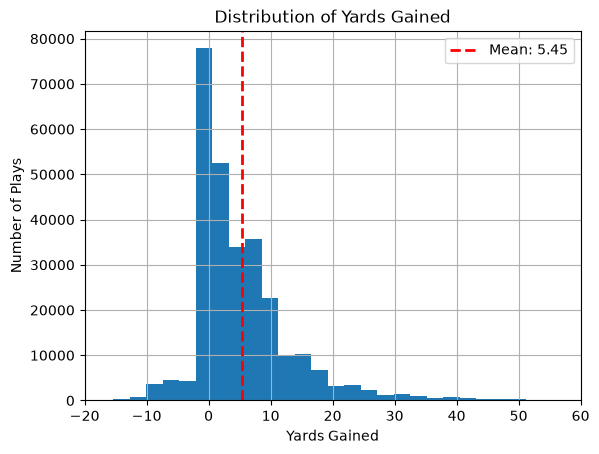

In [128]:
# Visualizing distribution of yards gained per play
import matplotlib.pyplot as plt
pbp["yards_gained"].hist(bins=50)

# Highlighting excpected yards per play
exp_yards = pbp["yards_gained"].mean()
plt.axvline(exp_yards, color="red", linestyle="dashed", 
            linewidth=2, label=f"Mean: {exp_yards:.2f}")

plt.xlabel("Yards Gained")
plt.ylabel("Number of Plays")
plt.title("Distribution of Yards Gained")
plt.xlim(-20, 60)
plt.legend()
plt.show()

In [129]:
# Basic summary statistics
pbp["yards_gained"].describe()

count    279917.000000
mean          5.448522
std           8.616379
min         -34.000000
25%           0.000000
50%           3.000000
75%           8.000000
max          99.000000
Name: yards_gained, dtype: float64

## Numerical Relationships w/ Yards Gained

In [130]:
# Indexing qualitative features
num_cols = [
    "quarter_seconds_remaining",
    "half_seconds_remaining",
    "game_seconds_remaining",
    "ydstogo",
    "yardline_100",
    "posteam_score",
    "defteam_score",
    "defenders_in_box",
    "number_of_pass_rushers",
    "temp",
    "wind",
]

# Indexing quantitative features
cat_cols = [
    "season",
    "week",
    "season_type",
    "posteam_type",
    "qtr",
    "down",
    "play_type",
    "offense_formation",
    "offense_personnel",
    "defense_personnel",
    "posteam",
    "defteam",
    "roof",
    "surface",
]

### Correlation Heatmap

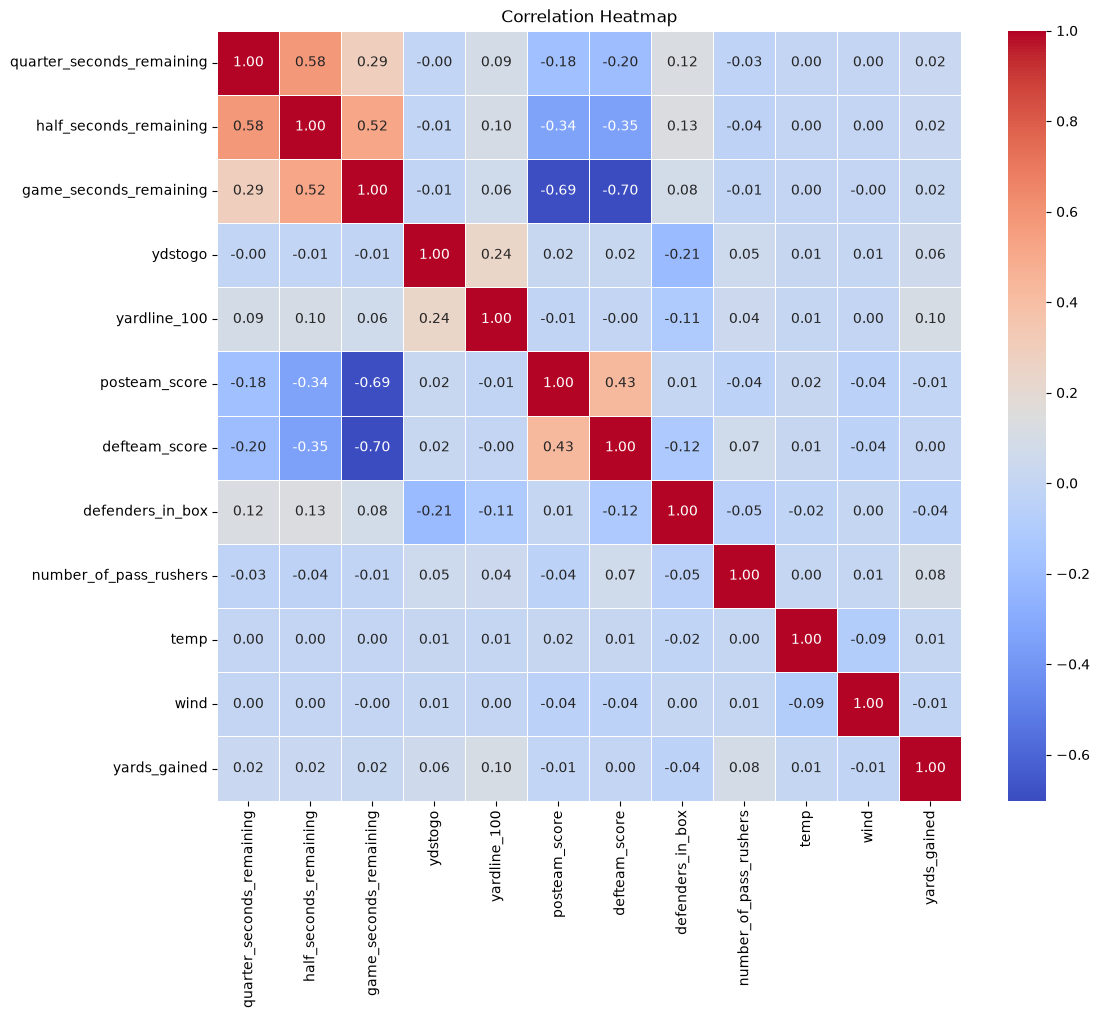

In [131]:
import seaborn as sns

# Compute correlations using only quantitative variables
corr = pbp[num_cols + ["yards_gained"]].corr()

# Plotting correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,    
    cmap="coolwarm", 
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

This correlation heatmap indicates that there are no features with even moderate correlation with yards gained. This method uses Pearson correlation which captures linear relationships, hinting that a linear model may be a weak predictor.


Even still, there are some observations we can make from this:
1) Yard line has the highest correlation with yards gained. This intuitively makes sense as if a play is starting in the red zone they have less field to work with, or if they are backed up they might settle for a short gain to make space.
2) Some qualitative features are correlated with each other. Interestingly, team scores have strong to moderate correlation with the time remaining. Another interesting relationship is the weak to moderate correlation between the number of defenders in the box and the number of yards until a first down which makes more sense as the defense might want to put more defenders in the box when the offense is near a first down.

## Categorical Relationships w/ Target Variable

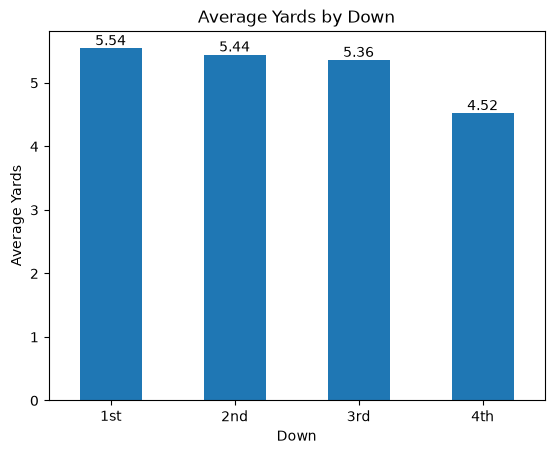

In [132]:
# Plotting average yards by down
ax = pbp.groupby("down")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xticks(ticks=range(4), labels=["1st", "2nd", "3rd", "4th"], rotation=0)
plt.xlabel("Down")
plt.ylabel("Average Yards")
plt.title("Average Yards by Down")
plt.show()

In [147]:
pbp["number_of_pass_rushers"].value_counts()

4     109414
0      42403
5      34168
3      11132
6       9500
7       2018
2       1633
1        527
8        232
9         18
10         2
45         1
44         1
Name: number_of_pass_rushers, dtype: Int64

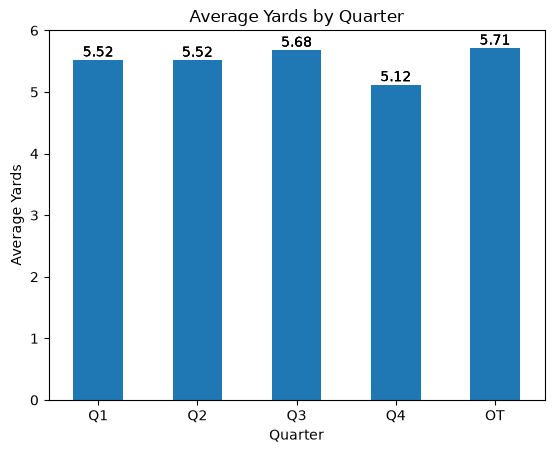

In [ ]:
# Plotting average yards by quarter
ax = pbp.groupby("qtr")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

ax = pbp.groupby("qtr")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xticks(ticks=range(5), labels=["Q1", "Q2", "Q3", "Q4", "OT"], rotation=0)
plt.xlabel("Quarter")
plt.ylabel("Average Yards")
plt.title("Average Yards by Quarter")
plt.show()

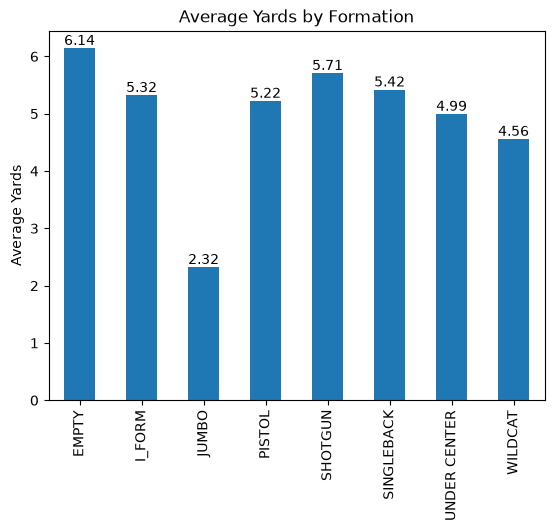

In [ ]:
# Plotting average yards by formation
ax = pbp.groupby("offense_formation")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xlabel("")
plt.ylabel("Average Yards")
plt.title("Average Yards by Formation")
plt.show()

## Examining Run vs. Pass Plays

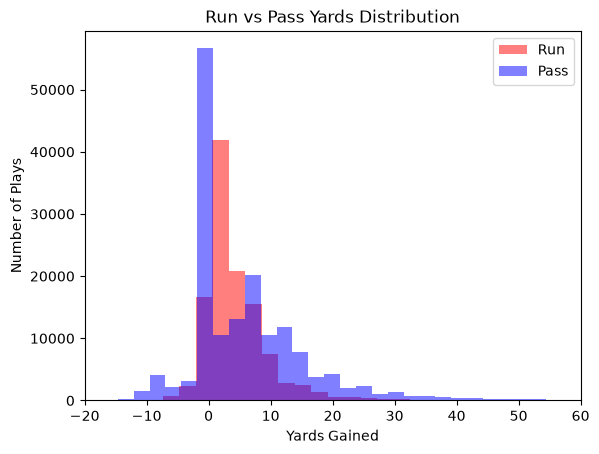

In [146]:
# Filtering run/pass plays
run_plays = pbp[pbp["play_type"] == "run"]["yards_gained"]
pass_plays = pbp[pbp["play_type"] == "pass"]["yards_gained"]

# Plotting overlayed distributions
plt.hist(run_plays, bins=50, alpha=0.5, color="red", label="Run")
plt.hist(pass_plays, bins=50, alpha=0.5, color="blue", label="Pass")

plt.xlabel("Yards Gained")
plt.ylabel("Number of Plays")
plt.title("Run vs Pass Yards Distribution")
plt.xlim(-20, 60)

plt.legend()
plt.show()

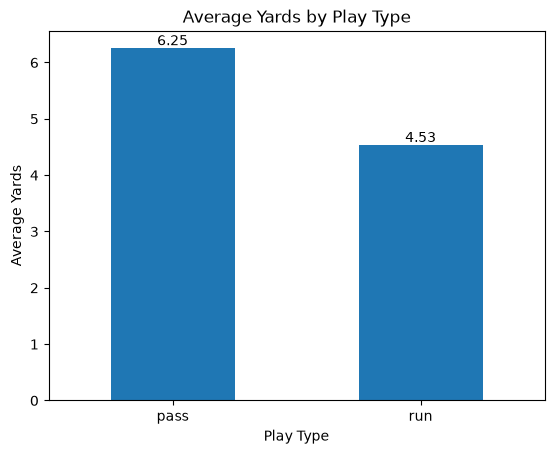

In [145]:
ax = pbp[pbp["play_type"] != "qb_kneel"].groupby("play_type")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xticks(rotation=0)
plt.xlabel("Play Type")
plt.ylabel("Average Yards")
plt.title("Average Yards by Play Type")
plt.show()

As we can see, run plays and pass plays have different expected yards per play as well distributions. While we do not know if a play is run or pass before the snap, it might be helpful to engineer a feature which models the probability of a pass play.

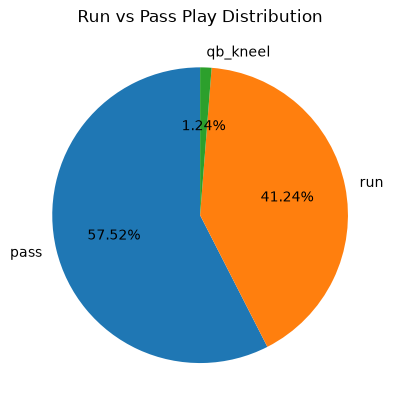

In [56]:
play_type_counts = pbp["play_type"].value_counts()

play_type_counts.plot.pie(
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Run vs Pass Play Distribution")
plt.ylabel("")
plt.show()

In [66]:
# Get play type counts per season
season_play_counts = pbp.groupby(["season", "play_type"]).size().unstack(fill_value=0)

# Convert to proportions
season_play_props = season_play_counts.div(season_play_counts.sum(axis=1), axis=0)

# Print formatted output
print(f'Proportion of play types per season:\n-------------------------------------')
for season in season_play_props.index:
    run_pct = season_play_props.loc[season].get("run", 0) * 100
    pass_pct = season_play_props.loc[season].get("pass", 0) * 100
    
    print(f"Season: {season}, Run: {run_pct:.1f}%, Pass: {pass_pct:.1f}%")

Proportion of play types per season:
-------------------------------------
Season: 2018, Run: 40.0%, Pass: 58.8%
Season: 2019, Run: 40.2%, Pass: 58.6%
Season: 2020, Run: 40.6%, Pass: 58.1%
Season: 2021, Run: 40.8%, Pass: 58.0%
Season: 2022, Run: 42.0%, Pass: 56.8%
Season: 2023, Run: 41.3%, Pass: 57.5%
Season: 2024, Run: 42.5%, Pass: 56.3%
Season: 2025, Run: 42.5%, Pass: 56.2%


Offensive tendencies typically vary by era. Mainly, NFL offenses today prioritize the passing game, whereas the running game was the focal point of offenses in the past. However, in the eight seasons of data we acquired, we notice that run/pass proportions seem to be about the same with slight increases in run plays throughout the years.